# 使用 PROC GREDUCE 为快速物流仪表盘精简配送区域地图细节

## 执行摘要

一家区域包裹承运商将其服务区域的边界存储为密集的多边形轮廓,导致路线规划仪表盘重绘缓慢。本笔记本为四个配送区域合成边界坐标,使用 **PROC GREDUCE** 为每个边界顶点标注 `DENSITY`(密度)层级,然后用 **PROC GMAP** 以精简后的细节层级渲染准时交付率分级地图,使地图绘制更快,同时每个区域仍可清晰辨认。

GREDUCE 将 96 个边界点划分为三个层级:10 个点位于 `DENSITY=0`,44 个位于 `DENSITY=2`,42 个位于 `DENSITY=3`。仅保留粗粒度层级(`DENSITY <= 2`)可将地图从 96 个顶点精简到 54 个——约减少 44%——而下方的并排对比显示四个区域依然清晰可辨。

## 数据来源

所有数据均由下方的 DATA 步在程序内生成——不涉及任何外部文件或网络访问。

| 数据集 | 行数 | 关键变量 | 说明 |
|---------|------|---------------|-------------|
| `zonemap` | 96(4个区域 x 24个顶点) | `zone`(ID)、`x`、`y` | 四个配送服务区域的合成闭合多边形边界坐标,每个区域是一个由 24 个顶点描出的带扰动椭圆,以便密度精简有内容可削减。 |
| `reducedmap` | 96 | 新增 `density` | PROC GREDUCE 的输出:每个边界点标注了 `DENSITY` 层级(此处为 0、2 或 3),用于选择性渲染。 |
| `coarsemap` | 54 | `reducedmap` 的子集 | `DENSITY <= 2` 子集——用于精简细节仪表盘地图的粗粒度、快速渲染层级。 |
| `zonekpi` | 4 | `zone`、`ontime_rate`、`parcels` | 每个区域一行响应数据:合成的准时交付百分比与每日包裹量,与地图关联用于分级地图渲染。 |

> **样本量说明。** 本环境以无许可模式运行,因此每个 DATA 步的输出观测数上限为 100 条。地图大小设定为 4 个区域 x 24 个顶点 = 96 个点,恰好落在该上限内;若为授权安装,每个区域会描出数百个顶点,此时 GREDUCE 的效果会更加明显。

# 使用 PROC GREDUCE 精简配送区域地图细节

物流运营者通过其**服务区域**——即某个仓储点负责的地理区域——的地图来可视化绩效表现。这些区域边界通常以测量级分辨率采集:每个多边形有大量顶点。当路线规划仪表盘同时重绘多个区域时,如此多的顶点细节会拖慢渲染速度,却并未在仪表盘的缩放级别上增加决策价值。

**PROC GREDUCE** 正是针对这一问题而设计。它检查每个多边形,为每个边界点标注一个 `DENSITY` 层级,其中 0 标记定义基本形状所必需的点,更高的层级则标记逐渐细化的细节。下游可以用 `WHERE density <= n` 选取某个层级,绘制出绘制速度更快、同时各区域仍可辨认的精简细节地图。

在本笔记本中,我们将:
1. 为四个配送区域合成边界轮廓。
2. 运行 PROC GREDUCE 分配 `DENSITY` 层级。
3. 查看各密度层级下点的分布情况。
4. 渲染完整细节与精简细节的准时交付分级地图并进行对比。

## 步骤 1 —— 合成区域边界地图

一个 SAS 地图数据集每个**边界顶点**占一条观测,包含一个用于命名区域的 `ID` 变量以及数值型的 `x`/`y` 坐标。我们用 24 个均匀分布的角度,将每个配送区域描绘成一个带扰动的椭圆,使多边形起始时具有足够的密度,以便精简处理有内容可做。

`call streaminit` 固定随机数流以保证可复现性,`rand('uniform')` 为边界添加轻微的不规则性,使轮廓读起来更像实测的区域,而非完美的椭圆。

In [1]:
数据 zonemap;
    调用 streaminit(20260531);
    /* 四个配送区域,每个区域是一个由24个顶点构成的带扰动椭圆。
       cx/cy = 区域中心, rx/ry = 标称半径(区域大小)。 */
    数组 cx[4] _temporary_ (12 32 20 40);
    数组 cy[4] _temporary_ (30 32 14 16);
    数组 rx[4] _temporary_ ( 8  9  6  7);
    数组 ry[4] _temporary_ ( 6  7  5  6);
    pi = constant('pi');
    nvtx = 23;                 /* 每条轮廓24个顶点 (0..23) */
    循环 zone = 1 到 4;
        循环 i = 0 到 nvtx;
            ang = 2 * pi * i / (nvtx + 1);
            /* 径向扰动: +/- 约6%的不规则海岸线式边缘 */
            jit = 1 + 0.12 * (rand('uniform') - 0.5);
            x = cx[zone] + rx[zone] * cos(ang) * jit;
            y = cy[zone] + ry[zone] * sin(ang) * jit;
            输出;
        结束;
    结束;
    保留 zone x y;
运行;

过程 均值 数据=zonemap n MIN MAX nmiss;
    分类 zone;
    变量 x y;
    标签 zone = "配送区域"
          x = "X坐标"
          y = "Y坐标";
运行;

                                                  The MEANS Procedure

                                             Analysis Variable : x X坐标

        配送区域                  N Obs        Minimum        Maximum         N Miss
        ------------------------------------------------------------------------
        1                        24      3.6053386     20.3284433              0
        2                        24     23.0107098     41.2087956              0
        3                        24     13.7607192     26.2351392              0
        4                        24     33.0535851     47.3028874              0
        ------------------------------------------------------------------------

                                             Analysis Variable : y Y坐标

        配送区域                  N Obs        Minimum        Maximum         N Miss
        ------------------------------------------------------------------------
        1                        24     23.9838655     


NOTE: DATA zonemap


NOTE: Wrote zonemap (96 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


PROC MEANS 表确认了合成几何形状:四个区域,每个区域恰好有 24 个边界点,`x`/`y` 取值范围合理,且没有缺失坐标。四个椭圆占据互不重叠的区域(区域1靠近 x=12,区域2靠近 x=32,区域3和区域4则位置更靠下),因此分级地图会呈现出四个清晰不同的区域。这些正是 PROC GREDUCE 将要精简的轮廓。

## 步骤 2 —— 使用 PROC GREDUCE 分配 DENSITY 层级

`ID` 语句指定定义各个区域单元的变量——此处为 `zone`。PROC GREDUCE 独立评估每个区域的多边形(采用道格拉斯-普克风格的化简算法),并在写回输入数据集时新增一个整数型 `density` 变量:层级 0 标记支撑基本形状的少数关键点,更高的层级则标记可优先舍弃的逐渐精细的细节。

我们让 GREDUCE 根据数据自行推导阈值,而不是强制固定层级大小,然后查看得到的分布情况。

                                                      各密度层级保留的边界点数                                                      

                                                   The FREQ Procedure

密度层级            Frequency    Percent
-------------------------------------
0                      10     10.42
2                      44     45.83
3                      42     43.75



NOTE: PROC GREDUCE data=zonemap

NOTE: PROC GREDUCE: 96 observations with DENSITY assigned
NOTE: PROC FREQ
NOTE: ODS plot written: freq_density.spec.json
NOTE: PROC FREQ statement used.


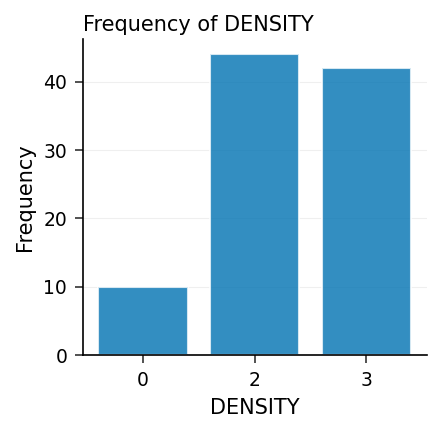

In [2]:
过程 GREDUCE 数据=zonemap out=reducedmap;
    id zone;
运行;

过程 频率 数据=reducedmap;
    TABLES DENSITY / nocum;
    标题 '各密度层级保留的边界点数';
    标签 DENSITY = "密度层级";
运行;

## 步骤 3 —— 查看各密度层级

频数表展示了 GREDUCE 如何为 96 个边界点分级:

| DENSITY(密度) | 点数 | 占比 |
|---------|--------|-------|
| 0 | 10 | 10.4% |
| 2 | 44 | 45.8% |
| 3 | 42 | 43.8% |

只有 10 个点属于最低层级(基本形状的锚点),其余 86 个点分布在层级 2 和 3 之间。对于仪表盘层级,我们保留全部 `DENSITY <= 2` 的点:这会保留 96 个点中的 54 个,舍弃 42 个最精细(`DENSITY=3`)的顶点。下方的 PROC MEANS 确认了粗粒度层级中每个区域保留 13–14 个顶点,而不是原来的 24 个。

In [3]:
过程 均值 数据=reducedmap n;
    分类 zone;
    条件 DENSITY <= 2;
    变量 x;
    标签 zone = "配送区域"
          x = "X坐标";
    标题 '仪表盘精度下各区域保留的顶点数 (DENSITY <= 2)';
运行;

                                             仪表盘精度下各区域保留的顶点数 (DENSITY <= 2)                                             

                                                  The MEANS Procedure

                                             Analysis Variable : X X坐标

        配送区域                  N Obs
        ---------------------------
        1                        14
        2                        13
        3                        14
        4                        13
        ---------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 4 —— 构建粗粒度地图与各区域绩效响应数据

我们将仪表盘层级具体化为 `coarsemap`(`DENSITY <= 2`),以便 PROC GMAP 可以直接绘制精简后的轮廓。我们还为每个区域合成一行 KPI 数据——**准时交付率**与**每日包裹量**——以 `zone` 为键,供 GMAP 为每个区域着色。

In [4]:
数据 coarsemap;
    设置 reducedmap;
    条件 DENSITY <= 2;
运行;

数据 zonekpi;
    调用 streaminit(771);
    循环 zone = 1 到 4;
        /* 准时率集中在92%附近,呈现真实的离散度 */
        ontime_rate = round(88 + 8 * rand('beta', 5, 2), 0.1);
        parcels     = round(2000 + 6000 * rand('uniform'));
        输出;
    结束;
运行;

过程 打印 数据=zonekpi noobs 标签;
    标签 zone = "配送区域"
          ontime_rate = "准时交付率(%)"
          parcels = "每日包裹量";
    标题 '各区域模拟配送KPI';
运行;

                                                       各区域模拟配送KPI                                                       

        配送区域            准时交付率(%)            每日包裹量
           1                92.6             4704
           2                95.6             2932
           3                93.4             2934
           4                94.6             2516




NOTE: DATA coarsemap


NOTE: Read 96 rows from reducedmap.
NOTE: Wrote coarsemap (54 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: DATA zonekpi


NOTE: Wrote zonekpi (4 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=zonekpi

NOTE: PROC PRINT completed: 4 observations printed, 3 variables


四个区域的合成准时率落在 92.6% 到 95.6% 之间,每日包裹量约在 2,500 到 4,700 件之间。区域2表现最佳,达到 95.6%;区域1表现最弱,为 92.6%。这些正是分级地图色带所编码的数值。

## 步骤 5 —— 渲染完整细节与精简细节分级地图

我们绘制两次相同的准时交付率分级地图:一次使用完整的 96 顶点 `reducedmap`,另一次使用 54 顶点的 `coarsemap`。`MAP=` 提供边界,`DATA=` 提供 KPI 响应数据,两者共用 `zone` ID。`CHORO` 语句按 `ontime_rate` 为每个区域填色,使用 `LEVELS=4` 色带,并用 `COUTLINE=` 绘制清晰的边框。对比两张地图可以看出精简在视觉上的代价。

                                                      完整精度:96个边界顶点                                                      




NOTE: Option TITLE changed to 完整精度:96个边界顶点.
NOTE: PROC GMAP map=reducedmap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 准时交付率.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds


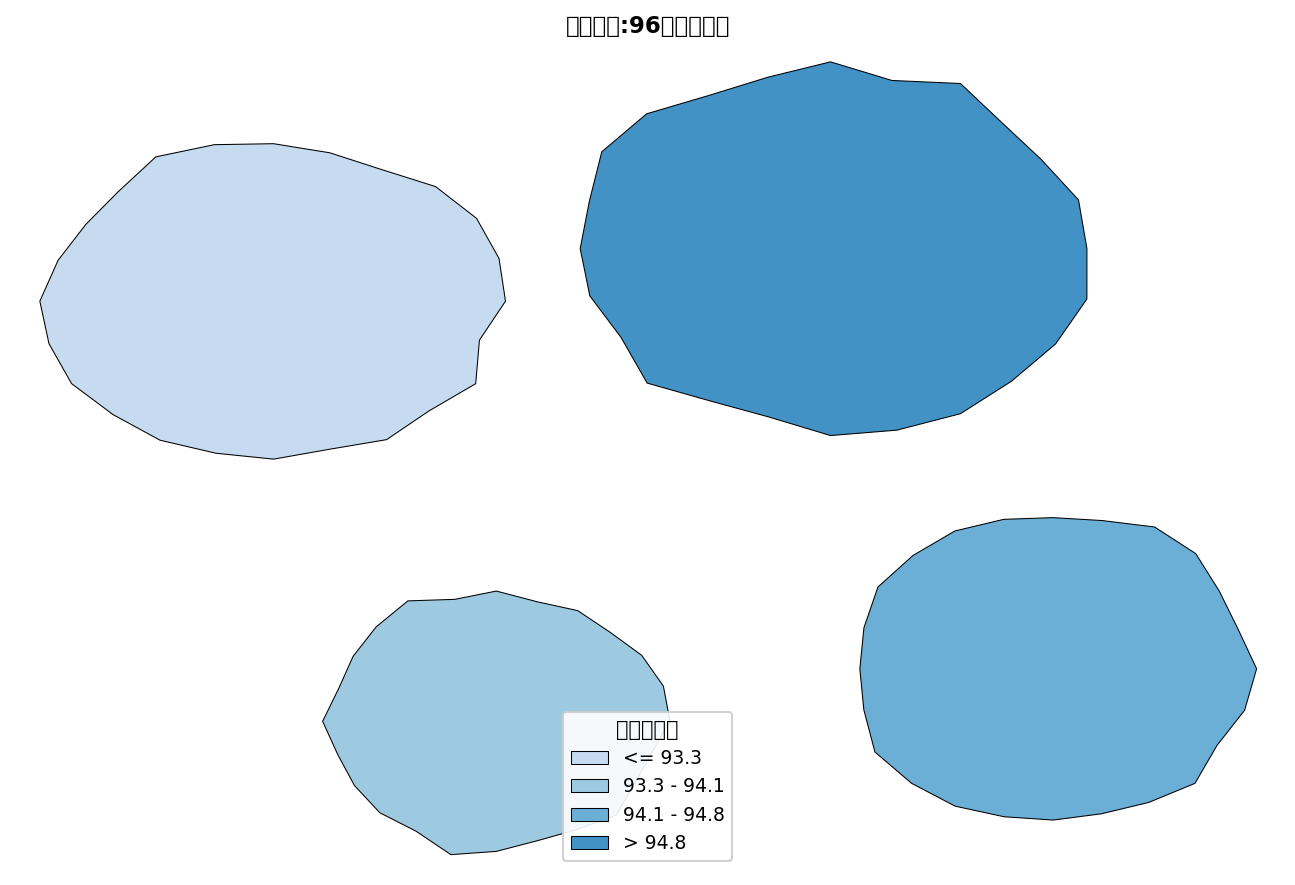

In [5]:
标题 '完整精度:96个边界顶点';
过程 GMAP map=reducedmap 数据=zonekpi;
    id zone;
    标签 zone = "配送区域"
          ontime_rate = "准时交付率";
    CHORO ontime_rate / levels=4 coutline=black;
运行;

                                               精简精度:54个顶点 (DENSITY <= 2)                                                




NOTE: Option TITLE changed to 精简精度:54个顶点 (DENSITY <= 2).
NOTE: PROC GMAP map=coarsemap data=zonekpi

NOTE: ODS plot written: gmap.spec.json
NOTE: PROC GMAP produced a choropleth map of variable 准时交付率.
NOTE: 4 map areas were shaded.

NOTE: PROC GMAP elapsed:
  wall  0.41 seconds
  cpu   0.41 seconds


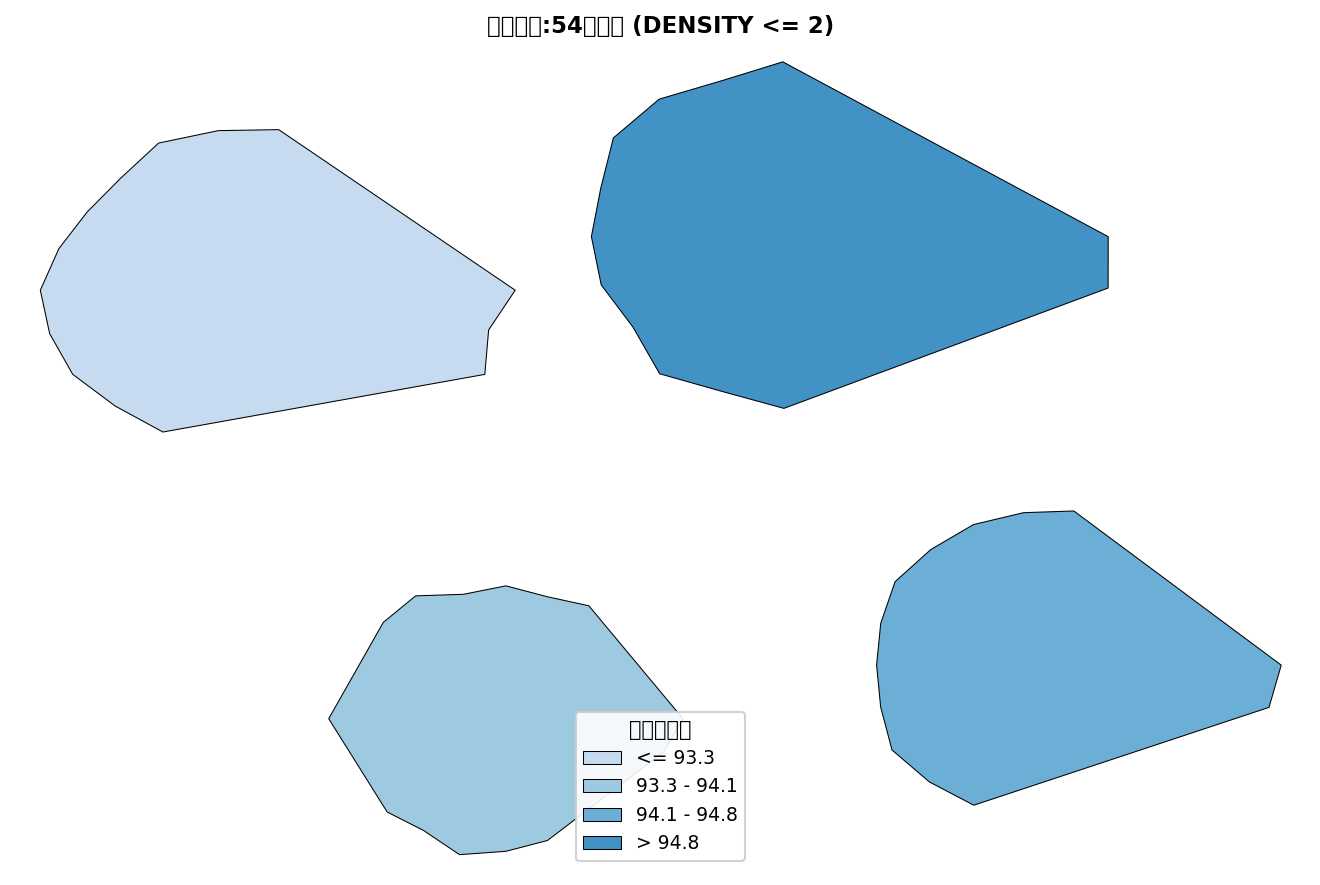

In [6]:
标题 '精简精度:54个顶点 (DENSITY <= 2)';
过程 GMAP map=coarsemap 数据=zonekpi;
    id zone;
    标签 zone = "配送区域"
          ontime_rate = "准时交付率";
    CHORO ontime_rate / levels=4 coutline=black;
运行;

## 结果解读

PROC GREDUCE 将每个 24 顶点的区域轮廓转化为一组分级的边界点(本次运行中为层级 0、2 和 3)。选择 `DENSITY <= 2` 层级将地图从 96 个顶点精简到 54 个——渲染器需要绘制的点减少了 44%——但并排的分级地图证实四个区域依然清晰可辨:精简地图的轮廓明显更为棱角分明,但每个区域仍保持其位置、大小和色带,因此无论使用哪张地图,运营者读到的记分卡结果是一致的。

该记分卡按准时交付率对各区域排名:区域2以 95.6% 领先(色带最深),区域3和区域4处于中等水平,约 93–95%,区域1以 92.6% 垫底(色带最浅)——这是规划人员应首先调查路线或仓储容量问题的区域。

由于此次精简是非破坏性的——完整细节的点仍保留在 `reducedmap` 中——同一个数据集既支持快速的仪表盘视图(`DENSITY <= 2`),也支持高分辨率的打印或审计视图(`DENSITY <= 3` 或完整点集),只需更改一个 `WHERE` 阈值,无需重新导入或重新精简几何数据。